In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, ArrowStyle
import matplotlib.patheffects as pe

plt.rcParams["font.family"] = "DejaVu Sans"

def add_box(ax, x, y, w, h, text,
            fc="#222222", ec="#888888",
            text_color="white", fontsize=9):
    """Draw a rounded rectangle with centered multi-line text."""
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.3",
        linewidth=1.0,
        edgecolor=ec,
        facecolor=fc,
        mutation_aspect=1.0,
    )
    ax.add_patch(box)
    ax.text(
        x + w/2, y + h/2, text,
        ha="center", va="center",
        fontsize=fontsize,
        color=text_color,
        path_effects=[pe.withStroke(linewidth=1, foreground="#000000")]
    )
    return box

def add_arrow(ax, x1, y1, x2, y2, color="white", lw=1.2):
    """Draw a simple arrow between two points."""
    ax.annotate(
        "",
        xy=(x2, y2), xycoords="data",
        xytext=(x1, y1), textcoords="data",
        arrowprops=dict(
            arrowstyle=ArrowStyle("-|>", head_width=4, head_length=6),
            color=color, linewidth=lw
        ),
    )


In [3]:
def draw_overall_flow():
    fig, ax = plt.subplots(figsize=(9, 4))
    fig.patch.set_facecolor("#050814")
    ax.set_facecolor("#050814")

    # Stage 1 block
    add_box(ax, 0.05, 0.35, 0.22, 0.30,
            "Stage 1\nXGBoost signal layer\n\n"
            "• technical indicators\n• Fama–French factors\n• macro features",
            fc="#263238", ec="#90A4AE", fontsize=8)

    # Stage 2 block
    add_box(ax, 0.38, 0.35, 0.24, 0.30,
            "Stage 2\nPPO DRL policy layer\n\n"
            "• state Sₜ from Stage 1\n• actor–critic networks\n• mean–CVaR reward",
            fc="#1B5E20", ec="#66BB6A", fontsize=8)

    # Outputs block
    add_box(ax, 0.72, 0.35, 0.22, 0.30,
            "Outputs\nportfolio-level\n\n"
            "• weights wₜ\n• P&L path\n• CVaR, Sharpe,\n  max drawdown",
            fc="#263238", ec="#90A4AE", fontsize=8)

    # arrows
    add_arrow(ax, 0.27, 0.50, 0.38, 0.50)   # Stage1 -> Stage2
    add_arrow(ax, 0.62, 0.50, 0.72, 0.50)   # Stage2 -> Outputs

    ax.text(
        0.5, 0.10,
        "Hierarchical signal-to-policy framework:\n"
        "Stage 1 generates interpretable signals; Stage 2 optimizes a risk-aware policy.",
        ha="center", va="center", fontsize=8, color="#CFD8DC"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# draw_overall_flow()


In [4]:
def draw_xgboost_architecture():
    fig, ax = plt.subplots(figsize=(9, 3))
    fig.patch.set_facecolor("#050814")
    ax.set_facecolor("#050814")

    ax.set_title("Stage 1 – XGBoost architecture (per asset)", color="white", fontsize=11, pad=12)

    # positions (x, width)
    x0, w = 0.05, 0.18
    gap = 0.06
    h = 0.45
    y = 0.30

    # Input feature vector
    add_box(ax, x0, y, w, h,
            "Feature vector\nX(i, t)\n\n"
            "• technical indicators\n• factor & macro lags",
            fc="#283593", ec="#5C6BC0", fontsize=8)

    # Tree ensemble block
    add_box(ax, x0 + w + gap, y, w, h,
            "XGBoost ensemble\n\n"
            "K regression trees\nf_i(X) = Σ f_{i,k}(X)",
            fc="#FFB300", ec="#FFA000", fontsize=8)

    # SHAP + outputs
    add_box(ax, x0 + 2*(w + gap), y, w, h,
            "Outputs\n\n"
            "• predicted return ŷ(i, t)\n"
            "• score(i, t)\n"
            "• SHAP attributions",
            fc="#00695C", ec="#26A69A", fontsize=8)

    # arrows
    add_arrow(ax, x0 + w, y + h/2, x0 + w + gap, y + h/2)
    add_arrow(ax, x0 + 2*w + gap, y + h/2, x0 + 2*w + 2*gap, y + h/2)

    # legend-like labels
    ax.text(0.5, 0.10,
            "Tree-based regression: input feature vector → XGBoost tree ensemble → prediction + SHAP.",
            ha="center", va="center", fontsize=8, color="#CFD8DC")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# draw_xgboost_architecture()


In [5]:
def draw_ppo_architecture(input_dim=128, hidden1=64, hidden2=64, n_actions=10):
    fig, ax = plt.subplots(figsize=(9, 4))
    fig.patch.set_facecolor("#050814")
    ax.set_facecolor("#050814")

    ax.set_title("Stage 2 – PPO actor–critic architecture", color="white", fontsize=11, pad=12)

    # Common geometry
    base_x, w = 0.06, 0.18
    gap = 0.06
    h = 0.20

    # ----------------- ACTOR (top row) -----------------
    y_top = 0.60

    add_box(ax, base_x, y_top, w, h,
            f"Actor input\nstate S_t\n({input_dim} dims)",
            fc="#283593", ec="#5C6BC0", fontsize=8)

    add_box(ax, base_x + w + gap, y_top, w, h,
            f"Hidden layer 1\n{hidden1} units\nReLU",
            fc="#3949AB", ec="#7986CB", fontsize=8)

    add_box(ax, base_x + 2*(w + gap), y_top, w, h,
            f"Hidden layer 2\n{hidden2} units\nReLU",
            fc="#3949AB", ec="#7986CB", fontsize=8)

    add_box(ax, base_x + 3*(w + gap), y_top, w, h,
            f"Actor output\npolicy mean/std\n({n_actions} actions)",
            fc="#1B5E20", ec="#66BB6A", fontsize=8)

    # arrows for actor
    add_arrow(ax, base_x + w,          y_top + h/2, base_x + w + gap,          y_top + h/2)
    add_arrow(ax, base_x + 2*w + gap,  y_top + h/2, base_x + 2*w + 2*gap,      y_top + h/2)
    add_arrow(ax, base_x + 3*w + 2*gap, y_top + h/2, base_x + 3*w + 3*gap,     y_top + h/2)

    ax.text(0.03, y_top + h + 0.02, "Actor network", color="#CFD8DC", fontsize=9, ha="left")

    # ----------------- CRITIC (bottom row) -----------------
    y_bot = 0.25

    add_box(ax, base_x, y_bot, w, h,
            f"Critic input\nstate S_t\n({input_dim} dims)",
            fc="#004D40", ec="#26A69A", fontsize=8)

    add_box(ax, base_x + w + gap, y_bot, w, h,
            f"Hidden layer 1\n{hidden1} units\nReLU",
            fc="#00695C", ec="#26A69A", fontsize=8)

    add_box(ax, base_x + 2*(w + gap), y_bot, w, h,
            f"Hidden layer 2\n{hidden2} units\nReLU",
            fc="#00695C", ec="#26A69A", fontsize=8)

    add_box(ax, base_x + 3*(w + gap), y_bot, w, h,
            "Critic output\nV(S_t)\nscalar",
            fc="#263238", ec="#90A4AE", fontsize=8)

    # arrows for critic
    add_arrow(ax, base_x + w,          y_bot + h/2, base_x + w + gap,          y_bot + h/2)
    add_arrow(ax, base_x + 2*w + gap,  y_bot + h/2, base_x + 2*w + 2*gap,      y_bot + h/2)
    add_arrow(ax, base_x + 3*w + 2*gap, y_bot + h/2, base_x + 3*w + 3*gap,     y_bot + h/2)

    ax.text(0.03, y_bot + h + 0.02, "Critic network", color="#CFD8DC", fontsize=9, ha="left")

    # caption
    ax.text(
        0.5, 0.05,
        "Both actor and critic share the same state representation S_t\n"
        "but have separate MLPs (two hidden layers) for policy and value.",
        ha="center", va="center", fontsize=8, color="#CFD8DC"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# draw_ppo_architecture()


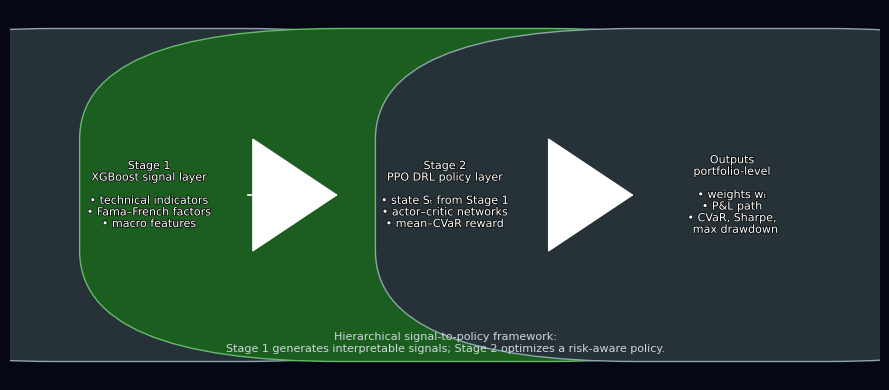

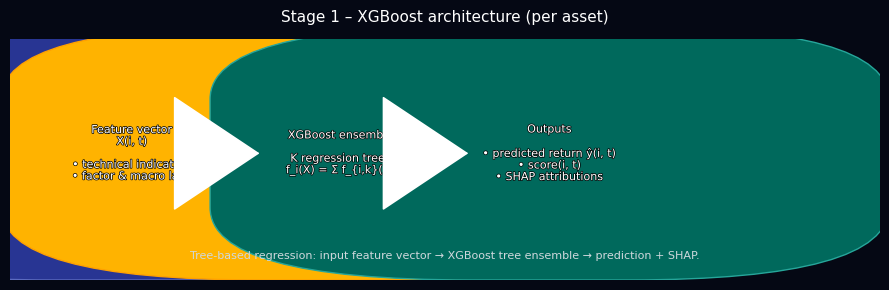

NameError: name 'state_dim' is not defined

In [6]:
if __name__ == "__main__":
    draw_overall_flow()
    draw_xgboost_architecture()
    draw_ppo_architecture(input_dim=state_dim, hidden1=64, hidden2=64, n_actions=N_assets)


SyntaxError: invalid character '•' (U+2022) (804775293.py, line 4)